Course Name: Deep Learning
Student Name: Vaishnavi Sadashiv Raut
Student ID: 202301100003
Date of Submission: 09/04/2026



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")   # rename downloaded file to data.csv

print("Shape:", df.shape)
print(df.head())

Shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_

In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
#Features & Target

# Drop unnecessary column
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert diagnosis to binary
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

y = df['diagnosis'].values.reshape(-1,1)
X = df.drop('diagnosis', axis=1).values

In [ ]:
#Normalization
mean = X.mean(axis=0)
std = X.std(axis=0)

X = (X - mean) / (std + 1e-8)


In [ ]:
#Train-Test Split
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * X.shape[0])

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
#Initialize Network
input_size = X_train.shape[1]
hidden_size = 10
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

epochs = 50
lr = 0.01

In [ ]:
#Activation Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [ ]:
#Training
losses = []

for epoch in range(epochs):

    # FORWARD
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # LOSS
    loss = -np.mean(y_train*np.log(A2+1e-8) + (1-y_train)*np.log(1-A2+1e-8))
    losses.append(loss)

    # BACKPROP
    dZ2 = A2 - y_train
    dW2 = np.dot(A1.T, dZ2) / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = np.dot(X_train.T, dZ1) / X_train.shape[0]
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # UPDATE
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    # PRINT EVERY EPOCH (ASSIGNMENT REQUIREMENT ✅)
    print(f"\nEpoch {epoch+1}")
    print("Loss:", loss)
    print("W1:\n", W1)
    print("W2:\n", W2)


Epoch 1
Loss: 0.6987339466252016
W1:
 [[ 0.04960225 -0.01387451  0.06482905  0.15235179 -0.02341703 -0.02340457
   0.15802832  0.0766937  -0.04690206  0.05423979]
 [-0.04638531 -0.04660267  0.02423381 -0.1912968  -0.1724928  -0.05622305
  -0.10121585  0.03139335 -0.09077426 -0.14124088]
 [ 0.14649435 -0.02262662  0.00681429 -0.14242508 -0.05443999  0.01110154
  -0.11499048  0.03751904 -0.06001761 -0.02918591]
 [-0.0602378   0.18518105 -0.00129109 -0.10572407  0.08225285 -0.12207561
   0.02099065 -0.19601528 -0.13277452  0.01967041]
 [ 0.07381231  0.01711336 -0.01153372 -0.03008523 -0.14785297 -0.07197986
  -0.04601367  0.10568736  0.0343849  -0.17631239]
 [ 0.03234992 -0.0385482  -0.06764038  0.0612089   0.10309858  0.09313559
  -0.08383585 -0.03096345  0.0331643   0.0975408 ]
 [-0.04798713 -0.01861318 -0.11057262 -0.11957212  0.08125094  0.13563292
  -0.00709674  0.10030312  0.03620812 -0.06452813]
 [ 0.03606395  0.15375164 -0.00351616  0.15651787 -0.26197631  0.08220014
   0.0088192

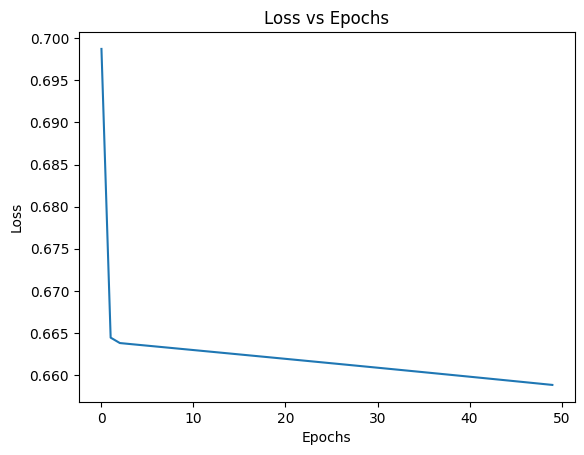

In [ ]:
#Loss Graph
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
#Predictions
Z1 = np.dot(X_test, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

preds = (A2 > 0.5).astype(int)

In [ ]:
#Accuracy / Precision / Recall
tp = np.sum((preds == 1) & (y_test == 1))
tn = np.sum((preds == 0) & (y_test == 0))
fp = np.sum((preds == 1) & (y_test == 0))
fn = np.sum((preds == 0) & (y_test == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.6666666666666666
Precision: 0.0
Recall: 0.0
